# Florida Building Code — Model Routing Benchmark Report

Reproducible analysis notebook. Reads raw per-request results from `results/*.jsonl` and the evaluation set from `data/fbc_eval_questions.csv` — nothing here is pre-aggregated or cached. Re-running this notebook end-to-end after re-running the harness (Lessons 1–6) regenerates every chart and number below from source.

Sections:
1. Load and merge results
2. Cold citation outcomes by tier — correct / wrong / abstained (Lessons 1–3)
3. Grounded vs. ungrounded citation accuracy — **the core Lesson 4 result**
4. Fine-tune break-even template (out of series scope; placeholder inputs)
5. Latency / cost tradeoff by model class
6. Lesson 5 — router selection comparison (which model each router picks, and whether it grounds)
7. Appendix — flagship vs. free-tier flash (cold): the calibration finding
8. Lesson 2 — the structured-output tradeoff

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cycler

# Anchor to the repo root by finding the dir that contains results/, so paths
# work whether the kernel cwd is analysis/ or the repo root (nbconvert vs IDE).
import os
_cwd = Path.cwd()
_repo = next((p for p in [_cwd, *_cwd.parents] if (p / "results").is_dir()), _cwd)
RESULTS_DIR = _repo / "results"
DATA_DIR = _repo / "data"
print(f"cwd={_cwd}  repo={_repo}  slm_present={(RESULTS_DIR / 'slm_raw.jsonl').exists()}")

# --- Shared visual system (palette validated via the dataviz skill) -----------
# Categorical hues in FIXED order (identity — assigned, never cycled past the list).
CATEGORICAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
# Reserved semantic colors for citation OUTCOMES (never reused as a data series).
STATUS = {"correct": "#0ca30c", "wrong": "#d03b3b", "abstained": "#adb5bd"}
# Stable color + label per model class, so a class keeps its hue across every chart.
MODEL_COLOR = {"foundation": "#2a78d6", "instruction_tuned": "#1baf7a", "slm": "#eda100"}
MODEL_LABEL = {"foundation": "Opus 4.8 (foundation)",
               "instruction_tuned": "Haiku 4.5 (instruction-tuned)",
               "slm": "phi3:mini (SLM, local)"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.prop_cycle": cycler(color=CATEGORICAL),
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 9, "figure.facecolor": "white",
})


cwd=C:\Users\ylrre\source\repos\fbc-model-routing-benchmark\analysis  repo=C:\Users\ylrre\source\repos\fbc-model-routing-benchmark  slm_present=True


## 1. Load and merge results

Expects one `.jsonl` file per model-class run, each row matching the `InferenceResult` schema from Lessons 1–3, plus a `_grounded` suffix on `question_id` for grounded runs (Lesson 4). Also loads the gold evaluation set to compute correctness.

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"WARNING: {path} not found — run the corresponding lesson harness first.")
        return pd.DataFrame()
    rows = [json.loads(line) for line in path.open(encoding="utf-8")]
    return pd.DataFrame(rows)

result_files = {
    "foundation": RESULTS_DIR / "foundation_raw.jsonl",
    "instruction_tuned": RESULTS_DIR / "instruction_tuned_raw.jsonl",
    "slm": RESULTS_DIR / "slm_raw.jsonl",
    "foundation_grounded": RESULTS_DIR / "foundation_grounded.jsonl",
    "instruction_tuned_grounded": RESULTS_DIR / "instruction_tuned_grounded.jsonl",
    "slm_grounded": RESULTS_DIR / "slm_grounded.jsonl",
}

frames = []
for label, path in result_files.items():
    df = load_jsonl(path)
    if not df.empty:
        df["run_label"] = label
        df["grounded"] = label.endswith("_grounded")
        frames.append(df)

results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

gold_path = DATA_DIR / "fbc_eval_questions.csv"
gold = pd.read_csv(gold_path) if gold_path.exists() else pd.DataFrame()
if gold.empty:
    print(f"WARNING: {gold_path} not found — create the evaluation set from Lesson 1 first.")

results.head()

,model_class,model_name,question_id,output,latency_ms,input_tokens,output_tokens,cost_usd,cited_section,error,repeat,category,gold_section,gold_section_norm,citation_match,run_label,grounded,schema_valid,tokens_per_sec,grounding_compliant
0,foundation,claude-opus-4-8,q001,"I don't have reliable, specific knowledge of t...",7157.0866,45,467,0.011900,10,None,1,numeric,FBC Building 1020.2,1020.2,False,foundation,False,NaN,NaN,NaN
1,foundation,claude-opus-4-8,q001,"I don't have reliable, specific knowledge of t...",8755.5286,45,513,0.013050,10,None,2,numeric,FBC Building 1020.2,1020.2,False,foundation,False,NaN,NaN,NaN
2,foundation,claude-opus-4-8,q001,I don't have the specific section numbers of t...,7990.3324,45,501,0.012750,10,None,3,numeric,FBC Building 1020.2,1020.2,False,foundation,False,NaN,NaN,NaN
3,foundation,claude-opus-4-8,q002,# Minimum Headroom Clearance in Means of Egres...,7608.4048,32,447,0.011335,None,None,1,numeric,FBC Building 1003.2,1003.2,False,foundation,False,NaN,NaN,NaN
4,foundation,claude-opus-4-8,q002,# Minimum Headroom Clearance in Means of Egres...,7753.5792,32,487,0.012335,1003.2,None,2,numeric,FBC Building 1003.2,1003.2,True,foundation,False,NaN,NaN,NaN


In [3]:
# Join results to gold answers on the base question_id (strip _grounded suffix)
import sys
sys.path.append("..")
from clients.citation_utils import extract_section_citation

if not results.empty and not gold.empty:
    results["base_question_id"] = results["question_id"].str.replace("_grounded", "", regex=False)
    merged = results.merge(
        gold, left_on="base_question_id", right_on="question_id", suffixes=("", "_gold")
    )

    # Failed requests (the harness records them with an `error` field) are a
    # reliability metric, not hallucinations — split them out before scoring.
    if "error" in merged.columns:
        failed = merged[merged["error"].notna()]
        if not failed.empty:
            print(
                f"{len(failed)} failed request(s) excluded from accuracy metrics "
                f"(reliability: {len(failed) / len(merged):.1%} failure rate)"
            )
        merged = merged[merged["error"].isna()].copy()

    # gold_section is prose-styled ("FBC Building 1020.2") while cited_section is
    # normalized ("1020.2") — normalize gold with the same deterministic extractor
    # before comparing. Raw string equality would score nearly every answer as a miss.
    merged["gold_section_norm"] = merged["gold_section"].astype(str).map(extract_section_citation)
    merged["citation_correct"] = (
        merged["cited_section"].notna()
        & merged["gold_section_norm"].notna()
        & (merged["cited_section"] == merged["gold_section_norm"])
    )
else:
    merged = pd.DataFrame()

merged.head()

9 failed request(s) excluded from accuracy metrics (reliability: 1.7% failure rate)


,model_class,model_name,question_id,output,latency_ms,input_tokens,output_tokens,cost_usd,cited_section,error,...,schema_valid,tokens_per_sec,grounding_compliant,base_question_id,question_id_gold,question,gold_section_gold,gold_answer,category_gold,citation_correct
0,foundation,claude-opus-4-8,q001,"I don't have reliable, specific knowledge of t...",7157.0866,45,467,0.011900,10,None,...,NaN,NaN,NaN,q001,q001,What section of the 2023 Florida Building Code...,FBC Building 1020.3,Section 1020.3 (Width and Capacity) of Chapter...,numeric,False
1,foundation,claude-opus-4-8,q001,"I don't have reliable, specific knowledge of t...",8755.5286,45,513,0.013050,10,None,...,NaN,NaN,NaN,q001,q001,What section of the 2023 Florida Building Code...,FBC Building 1020.3,Section 1020.3 (Width and Capacity) of Chapter...,numeric,False
2,foundation,claude-opus-4-8,q001,I don't have the specific section numbers of t...,7990.3324,45,501,0.012750,10,None,...,NaN,NaN,NaN,q001,q001,What section of the 2023 Florida Building Code...,FBC Building 1020.3,Section 1020.3 (Width and Capacity) of Chapter...,numeric,False
3,foundation,claude-opus-4-8,q002,# Minimum Headroom Clearance in Means of Egres...,7608.4048,32,447,0.011335,None,None,...,NaN,NaN,NaN,q002,q002,What is the minimum headroom clearance require...,FBC Building 1003.3.1,A minimum headroom of 80 inches (2032 mm) must...,numeric,False
4,foundation,claude-opus-4-8,q002,# Minimum Headroom Clearance in Means of Egres...,7753.5792,32,487,0.012335,1003.2,None,...,NaN,NaN,NaN,q002,q002,What is the minimum headroom clearance require...,FBC Building 1003.3.1,A minimum headroom of 80 inches (2032 mm) must...,numeric,True


## 2. Cold citation outcomes by tier (no grounding)

The headline from Lessons 1–3, split three ways — **correct / wrong (hallucination) / abstained**. A single "hallucination rate" would hide the real finding: the *rate* of failure is similar across tiers, but the *shape* is not. The flagship abstains, the forced-schema model fabricates, the tiny local model mostly doesn't know — same poor correctness, very different risk profiles.

,correct,wrong,abstained,n
Opus 4.8 (foundation),26.5%,31.8%,41.7%,132
Haiku 4.5 (instruction-tuned),31.8%,67.4%,0.8%,132
"phi3:mini (SLM, local)",7.9%,39.4%,52.8%,127


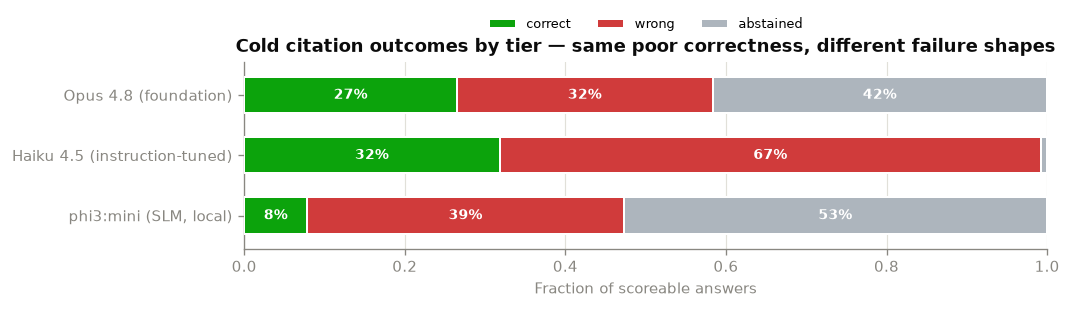

Cold, no tier is usable — and each FAILS DIFFERENTLY. The flagship abstains (calibrated 'I don't know'); the forced-schema model can't abstain so it fabricates; the tiny local model mostly doesn't know. A confident WRONG citation is the dangerous failure for a compliance tool — which is exactly what the cheap schema model does most.


In [4]:
if not merged.empty:
    cold = merged[~merged["grounded"]]
    sc = cold[cold["gold_section_norm"].notna()]   # scoreable (drop q017: date, no section)

    def outcomes(mc):
        d = sc[sc["model_class"] == mc]
        n = len(d)
        correct = int(d["citation_correct"].sum())
        abstained = int(d["cited_section"].isna().sum())
        return {"correct": correct / n, "wrong": (n - correct - abstained) / n,
                "abstained": abstained / n, "n": n}

    order = [m for m in ["foundation", "instruction_tuned", "slm"] if m in set(sc["model_class"])]
    tbl = pd.DataFrame({MODEL_LABEL[m]: outcomes(m) for m in order}).T
    display(tbl.style.format({"correct": "{:.1%}", "wrong": "{:.1%}",
                              "abstained": "{:.1%}", "n": "{:.0f}"}))

    fig, ax = plt.subplots(figsize=(9, 0.9 + 0.6 * len(order)))
    tbl[["correct", "wrong", "abstained"]].plot(
        kind="barh", stacked=True, ax=ax,
        color=[STATUS["correct"], STATUS["wrong"], STATUS["abstained"]],
        edgecolor="white", linewidth=1.2, width=0.6, zorder=3)
    for i, m in enumerate(order):                    # direct segment labels
        left = 0
        for k in ("correct", "wrong", "abstained"):
            v = tbl.loc[MODEL_LABEL[m], k]
            if v > 0.06:
                ax.text(left + v / 2, i, f"{v:.0%}", ha="center", va="center",
                        color="white", fontsize=8.5, weight="bold", zorder=4)
            left += v
    ax.set_xlim(0, 1); ax.set_xlabel("Fraction of scoreable answers")
    ax.set_title("Cold citation outcomes by tier — same poor correctness, different failure shapes")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.10), ncol=3, fontsize=8, frameon=False)
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()

    print("Cold, no tier is usable — and each FAILS DIFFERENTLY. The flagship abstains (calibrated "
          "'I don't know'); the forced-schema model can't abstain so it fabricates; the tiny local "
          "model mostly doesn't know. A confident WRONG citation is the dangerous failure for a "
          "compliance tool — which is exactly what the cheap schema model does most.")
else:
    print("No merged data yet — populate results/ and data/ from Lessons 1-3.")

### Breakdown by query category

Expect `jurisdiction_amendment` questions (Naples/Collier-specific) to show the highest hallucination rate across all model classes — these are the most under-represented in any model's pretraining corpus.

model_class,foundation,instruction_tuned,slm
category,,,
definitional,0.000000,0.416667,0.000000
jurisdiction_amendment,0.287879,0.318182,0.107692
numeric,0.270833,0.291667,0.066667
state_amendment,0.333333,0.222222,0.000000


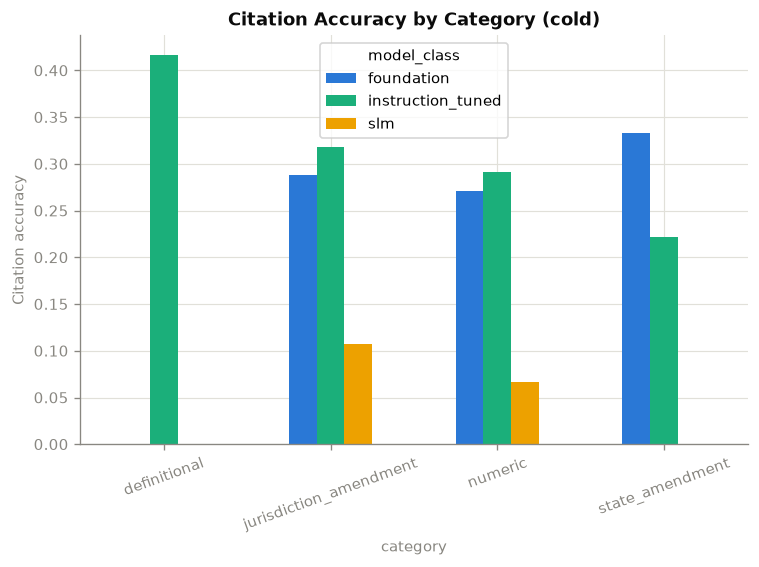

In [5]:
if not merged.empty:
    cold = merged[~merged["grounded"]]
    pivot = (
        cold.groupby(["category", "model_class"])["citation_correct"]
        .mean()
        .unstack("model_class")
    )
    display(pivot)
    pivot.plot(kind="bar", title="Citation Accuracy by Category (cold)")
    plt.ylabel("Citation accuracy")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

### Exhibit A — what failure actually looks like

Three archetypes recur in the cold transcripts, and they are not equally dangerous:

1. **Base-code substitution** — the model answers the *Florida* question from the generic ICC model code it saw far more of in pretraining (q002 opens "According to the International Building Code…"; q023 answers from the IRC). Florida's deltas from the base code are exactly where compliance risk lives.
2. **Plausible near-misses** — citations in the right neighborhood but the wrong section (`62-81` for `62-80`, `22-106` for `22-28`, `105.2.2` for `105.2.4`). Worst case for a compliance tool: they look verifiable and pass a smell test.
3. **Outright fabrication** — invented instruments and values: "Ordinance 2021-03" (does not exist), a 300-ft sea-turtle buffer (actual: 100 ft), a 30-ft Estates front setback (actual: 75 ft).

**Scoring note:** exact-match is conservative — a few "wrong" rows cite a *subsection* of the correct section (e.g. `1609.1.1` vs gold `1609`). Eyeball `results/hallucinated_citations.csv` before quoting the headline number; that review is part of the method, not an afterthought.

In [6]:
# Exhibit A — failure cases straight from the transcripts (publication plan §6:
# lead with these). Also exports every wrong-citation row for the repo.
if not merged.empty:
    cold = merged[~merged["grounded"]]
    scoreable = cold[cold["gold_section_norm"].notna()]
    wrong = scoreable[scoreable["cited_section"].notna() & ~scoreable["citation_correct"]]

    export_cols = ["question_id", "model_name", "category", "question",
                   "cited_section", "gold_section_norm", "output"]
    wrong[export_cols].to_csv(RESULTS_DIR / "hallucinated_citations.csv", index=False)
    print(f"Wrote {len(wrong)} wrong-citation rows -> {RESULTS_DIR / 'hallucinated_citations.csv'}\n")

    def exhibit(qid: str, label: str, chars: int = 550) -> None:
        r = cold[cold["question_id"] == qid]
        if r.empty:
            return
        r = r.iloc[0]
        print("=" * 90)
        print(f"[{label}]")
        print(f"Q ({r.question_id}, {r.category}): {r.question}")
        print(f"GOLD: {r.gold_section}  |  MODEL CITED: {r.cited_section}")
        print(f"A: {r.output[:chars]}")
        print()

    exhibit("q002", "Base-code substitution — answers the FLORIDA code question from the generic IBC")
    exhibit("q029", "Fabrication — invents 'Ordinance 2021-03' (the real answer is Ordinance 2020-48)")
    exhibit("q035", "Confidently wrong value — 30 ft vs the actual 75 ft Estates front setback")
    exhibit("q037", "Plausible near-miss — right rule, wrong number (300 ft vs 100 ft) and wrong subsection")

Wrote 181 wrong-citation rows -> C:\Users\ylrre\source\repos\fbc-model-routing-benchmark\results\hallucinated_citations.csv

[Base-code substitution — answers the FLORIDA code question from the generic IBC]
Q (q002, numeric): What is the minimum headroom clearance required over a walking surface in the means of egress?
GOLD: FBC Building 1003.2  |  MODEL CITED: None
A: # Minimum Headroom Clearance in Means of Egress

## General Requirement
Under the **International Building Code (IBC)** and **NFPA 101 (Life Safety Code)**, the minimum headroom clearance in the means of egress is:

**7 feet 6 inches (2,286 mm)**

This applies to the ceiling height above walking surfaces including corridors, aisles, and other egress components.

## Exceptions

There are several common exceptions where reduced headroom is permitted:

- **Door openings:** Minimum **6 feet 8 inches (2,032 mm)** clearance is allowed.

- **Stairways

[Fabrication — invents 'Ordinance 2021-03' (the real answer is Ordinance 202

## 3. Grounded vs. ungrounded citation accuracy

The core Lesson 4 result: how much does injecting the actual FBC/Naples passage as context improve citation accuracy per model class? Expect the SLM to show the largest relative gain.

grounded,ungrounded,grounded,delta
model_class,,,
instruction_tuned,0.318182,0.772727,0.454545
slm,0.078740,0.525000,0.446260
foundation,0.265152,0.590909,0.325758


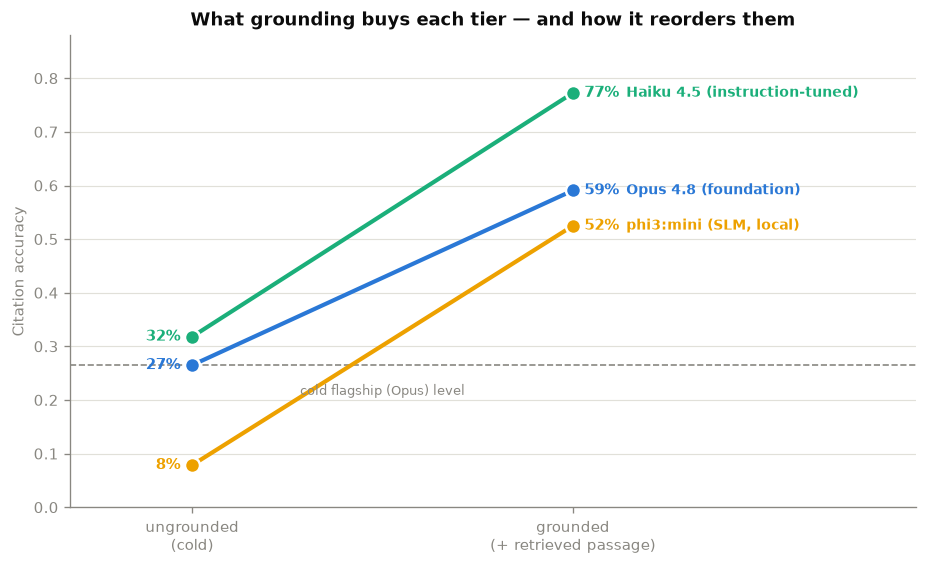

Retrieval is the highest-leverage move in the series: +33 to +46 points for EVERY tier. The reordering is the headline — grounded phi3 (local, ~free, offline) lands ABOVE the cold flagship. Cheap-local + good retrieval beats an expensive model alone; the model tier matters far less than whether you ground it.


In [7]:
if not merged.empty:
    # Score only rows with a scoreable gold (drops q017, a date with no code
    # section; API errors are already excluded upstream) so the cold rates here
    # match the Section 2 outcome table exactly and every doc quotes one set of
    # numbers.
    scoreable = merged[merged["gold_section_norm"].notna()]
    grounding_effect = (
        scoreable.groupby(["model_class", "grounded"])["citation_correct"]
        .mean()
        .unstack("grounded")
        .rename(columns={False: "ungrounded", True: "grounded"})
    )

    # Until the Lesson 4 grounded runs exist (results/*_grounded.jsonl), only the
    # ungrounded column is present — show what we have instead of KeyError-ing.
    if {"ungrounded", "grounded"}.issubset(grounding_effect.columns):
        grounding_effect["delta"] = grounding_effect["grounded"] - grounding_effect["ungrounded"]
        display(grounding_effect.sort_values("delta", ascending=False))

        # Slope chart: each tier's jump from ungrounded -> grounded. The LIFT is a
        # literal upward slope, and the reordering (grounded cheap-local crossing
        # ABOVE the cold flagship) is the economic headline of the whole series.
        fig, ax = plt.subplots(figsize=(7.8, 4.8))
        order = [m for m in ["foundation", "instruction_tuned", "slm"] if m in grounding_effect.index]
        for m in order:
            u = grounding_effect.loc[m, "ungrounded"]; g = grounding_effect.loc[m, "grounded"]
            col = MODEL_COLOR[m]
            ax.plot([0, 1], [u, g], color=col, lw=2.5, marker="o", markersize=9,
                    markeredgecolor="white", markeredgewidth=1.5, zorder=3)
            ax.text(-0.03, u, f"{u:.0%}", ha="right", va="center", color=col, fontsize=9, weight="bold")
            ax.text(1.03, g, f"{g:.0%}", ha="left", va="center", color=col, fontsize=9, weight="bold")
            ax.text(1.14, g, MODEL_LABEL[m], ha="left", va="center", color=col, fontsize=8.5, weight="bold")

        # Reference line at the cold flagship's level — cheap grounded tiers cross above it.
        if "foundation" in grounding_effect.index:
            cold_flag = grounding_effect.loc["foundation", "ungrounded"]
            ax.axhline(cold_flag, color=MUTED, ls="--", lw=1, zorder=1)
            ax.text(0.5, cold_flag - 0.035, "cold flagship (Opus) level", ha="center", va="top",
                    color=MUTED, fontsize=8)

        ax.set_xticks([0, 1]); ax.set_xticklabels(["ungrounded\n(cold)", "grounded\n(+ retrieved passage)"])
        ax.set_ylabel("Citation accuracy"); ax.set_ylim(0, 0.88); ax.set_xlim(-0.32, 1.9)
        ax.set_title("What grounding buys each tier — and how it reorders them")
        ax.grid(axis="x", visible=False)
        plt.tight_layout()
        # Exported for the write-ups (README / LinkedIn) — regenerated on every run.
        fig.savefig(RESULTS_DIR / "grounding_slope.png", dpi=200, bbox_inches="tight")
        plt.show()

        print("Retrieval is the highest-leverage move in the series: +33 to +46 points for EVERY tier. "
              "The reordering is the headline — grounded phi3 (local, ~free, offline) lands ABOVE the "
              "cold flagship. Cheap-local + good retrieval beats an expensive model alone; the model "
              "tier matters far less than whether you ground it.")
    else:
        have = ", ".join(map(str, grounding_effect.columns)) or "none"
        print(
            f"Only '{have}' runs found — the grounded/ungrounded comparison needs both. "
            "Run the Lesson 4 grounded variant to populate results/*_grounded.jsonl, "
            "then re-run this cell."
        )
        display(grounding_effect)
else:
    print("No merged data yet — populate results/ and data/ from Lessons 1-3.")

## 4. Fine-tune break-even template (out of series scope)

Fine-tuning is deliberately out of the series' scope (see the README scope note) — the decision is economic, so this template answers it with a break-even curve, parameterized with cost-per-request figures measured in Section 5 below (not assumed) plus a fine-tuning cost estimate you supply.

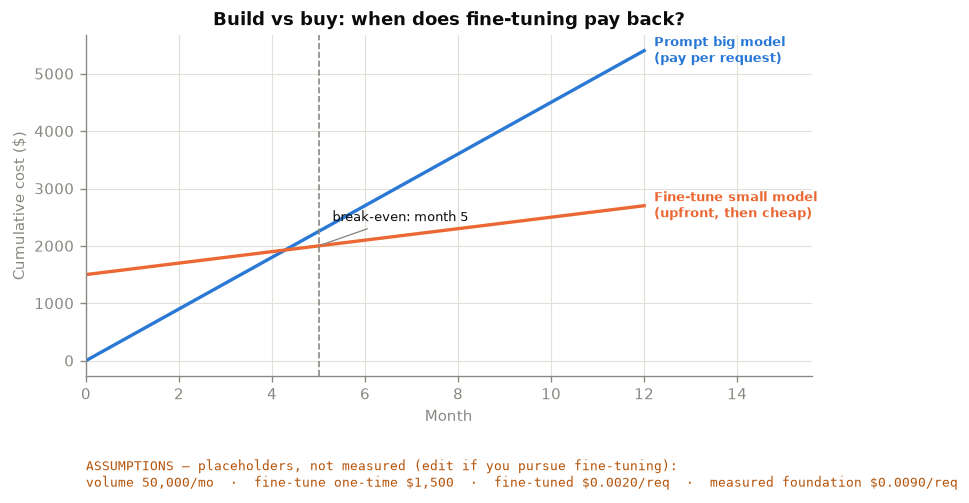

Break-even at month 5 UNDER THESE PLACEHOLDER ASSUMPTIONS. This is a template, not a finding — the crossover moves with request volume and the real fine-tune quote (see the README scope note). Below ~a few thousand requests/month, fine-tuning typically never pays off.


In [8]:
# Build vs buy: prompt a big model per request (rent) vs fine-tune a small one (own).
# NOTE: this chart is a TEMPLATE. The three cost inputs below are PLACEHOLDERS —
# real numbers would come from an actual fine-tuning run. The chart is only as true as these assumptions.
ASSUMPTIONS = {
    "monthly_requests": 50_000,
    "finetune_one_time_cost_usd": 1500.0,   # data curation + one QLoRA training run
    "finetuned_cost_per_req_usd": 0.002,    # amortized SLM inference
}

def breakeven_analysis(rent_per_req, finetune_one_time, own_per_req, monthly, horizon=12):
    months = list(range(0, horizon + 1))
    rent = [rent_per_req * monthly * m for m in months]
    own = [finetune_one_time + own_per_req * monthly * m for m in months]
    be = next((m for m, (r, o) in zip(months, zip(rent, own)) if o < r), None)
    return months, rent, own, be

# Foundation cost/request is MEASURED from the actual run (not assumed).
if not merged.empty and "cost_usd" in merged.columns:
    measured_foundation_cost = merged.loc[merged["model_class"] == "foundation", "cost_usd"].mean()
else:
    measured_foundation_cost = 0.02

months, rent, own, be = breakeven_analysis(
    measured_foundation_cost,
    ASSUMPTIONS["finetune_one_time_cost_usd"],
    ASSUMPTIONS["finetuned_cost_per_req_usd"],
    ASSUMPTIONS["monthly_requests"],
)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(months, rent, color=MODEL_COLOR["foundation"], lw=2)
ax.plot(months, own, color="#eb6834", lw=2)
ax.text(months[-1], rent[-1], "  Prompt big model\n  (pay per request)",
        color=MODEL_COLOR["foundation"], va="center", fontsize=8, weight="bold")
ax.text(months[-1], own[-1], "  Fine-tune small model\n  (upfront, then cheap)",
        color="#eb6834", va="center", fontsize=8, weight="bold")
if be is not None:
    ax.axvline(be, color=MUTED, ls="--", lw=1)
    ax.annotate(f"break-even: month {be}", xy=(be, own[be]),
                xytext=(be + 0.3, max(rent) * 0.45), color=INK, fontsize=8,
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_xlabel("Month"); ax.set_ylabel("Cumulative cost ($)")
ax.set_title("Build vs buy: when does fine-tuning pay back?")
ax.margins(x=0.20); ax.set_xlim(0, months[-1] * 1.30)

banner = ("ASSUMPTIONS — placeholders, not measured (edit if you pursue fine-tuning):\n"
          f"volume {ASSUMPTIONS['monthly_requests']:,}/mo  ·  "
          f"fine-tune one-time ${ASSUMPTIONS['finetune_one_time_cost_usd']:,.0f}  ·  "
          f"fine-tuned ${ASSUMPTIONS['finetuned_cost_per_req_usd']:.4f}/req  ·  "
          f"measured foundation ${measured_foundation_cost:.4f}/req")
ax.text(0.0, -0.24, banner, transform=ax.transAxes, fontsize=7.5,
        color="#b45309", va="top", family="monospace")
plt.tight_layout(); plt.show()

print(f"Break-even at month {be} UNDER THESE PLACEHOLDER ASSUMPTIONS. This is a template, "
      "not a finding — the crossover moves with request volume and the real fine-tune quote "
      "(see the README scope note). Below ~a few thousand requests/month, fine-tuning typically never pays off.")


## 5. Latency / cost tradeoff by query category

,model_class,p50_latency_ms,p95_latency_ms,mean_cost_usd,citation_accuracy,cost_per_correct_usd
0,foundation,6631.8875,11096.31345,0.010455,0.265152,0.039432
1,instruction_tuned,839.9742,2953.85934,0.000357,0.318182,0.001122
2,slm,68386.7626,156451.94306,0.001056,0.078740,0.013415


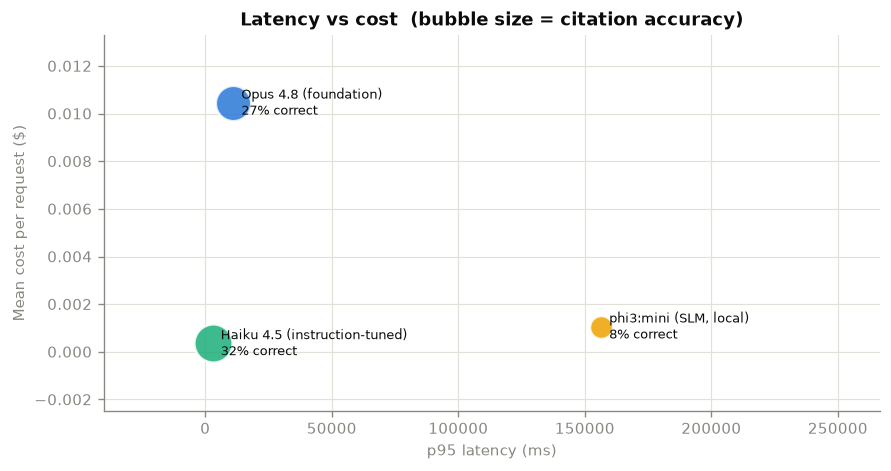

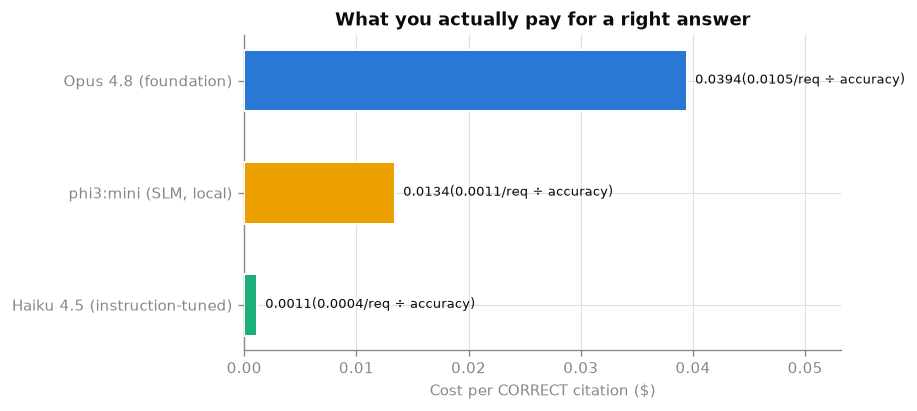

Wrote C:\Users\ylrre\source\repos\fbc-model-routing-benchmark\results\summary_table.csv
Per CORRECT citation the cheap model is even FURTHER ahead (~35x cheaper, not 29x) — Haiku is both cheaper per request AND slightly more accurate here. But this metric counts only right answers; it is blind to Haiku's 67% WRONG rate. In compliance a confident wrong citation carries real downstream cost, so cost-per-correct FLATTERS the cheap model. The missing term — the cost of being confidently wrong — is what grounding (Lesson 4) attacks; that, not model tier, is the main lever.


In [9]:
if not merged.empty:
    cold = merged[~merged["grounded"]]
    # Accuracy over scoreable rows only (same denominator as Section 2);
    # latency and cost stay over ALL cold requests — q017 still costs money.
    cold_sc = cold[cold["gold_section_norm"].notna()]
    summary = (
        cold.groupby("model_class")
        .agg(
            p50_latency_ms=("latency_ms", "median"),
            p95_latency_ms=("latency_ms", lambda s: s.quantile(0.95)),
            mean_cost_usd=("cost_usd", "mean"),
        )
        .reset_index()
    )
    summary["citation_accuracy"] = summary["model_class"].map(
        cold_sc.groupby("model_class")["citation_correct"].mean())
    # The honest unit cost: dollars per CORRECT citation, not per request.
    summary["cost_per_correct_usd"] = summary["mean_cost_usd"] / summary["citation_accuracy"]
    display(summary)

    # (1) latency vs cost, bubble = accuracy
    fig, ax = plt.subplots(figsize=(7.5, 4))
    for _, r in summary.iterrows():
        c = MODEL_COLOR.get(r["model_class"], "#4a3aa7")
        ax.scatter(r["p95_latency_ms"], r["mean_cost_usd"],
                   s=1400 * r["citation_accuracy"] + 80, color=c, alpha=0.85,
                   edgecolor="white", linewidth=1.5, zorder=3)
        ax.annotate(f"  {MODEL_LABEL.get(r['model_class'], r['model_class'])}\n  {r['citation_accuracy']:.0%} correct",
                    (r["p95_latency_ms"], r["mean_cost_usd"]), color=INK, fontsize=8, va="center")
    ax.set_xlabel("p95 latency (ms)"); ax.set_ylabel("Mean cost per request ($)")
    ax.set_title("Latency vs cost  (bubble size = citation accuracy)")
    ax.margins(0.28)
    _x0, _x1 = ax.get_xlim(); ax.set_xlim(_x0, _x1 + (_x1 - _x0) * 0.28)
    plt.tight_layout(); plt.show()

    # (2) cost per CORRECT citation — reframes "cheap"
    s2 = summary.sort_values("cost_per_correct_usd")
    fig, ax = plt.subplots(figsize=(7.5, 1.4 + 0.7 * len(s2)))
    ys = [MODEL_LABEL.get(m, m) for m in s2["model_class"]]
    bars = ax.barh(ys, s2["cost_per_correct_usd"],
                   color=[MODEL_COLOR.get(m, "#4a3aa7") for m in s2["model_class"]],
                   height=0.55, edgecolor="white", linewidth=1.2, zorder=3)
    for b, v, req in zip(bars, s2["cost_per_correct_usd"], s2["mean_cost_usd"]):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2,
                f"  ${v:.4f}   (${req:.4f}/req ÷ accuracy)",
                va="center", fontsize=8, color=INK)
    ax.set_xlabel("Cost per CORRECT citation ($)")
    ax.set_title("What you actually pay for a right answer")
    ax.margins(x=0.35)
    plt.tight_layout(); plt.show()

    summary.to_csv(RESULTS_DIR / "summary_table.csv", index=False)
    print(f"Wrote {RESULTS_DIR / 'summary_table.csv'}")
    print("Per CORRECT citation the cheap model is even FURTHER ahead (~35x cheaper, not 29x) — "
          "Haiku is both cheaper per request AND slightly more accurate here. But this metric counts "
          "only right answers; it is blind to Haiku's 67% WRONG rate. In compliance a confident wrong "
          "citation carries real downstream cost, so cost-per-correct FLATTERS the cheap model. The "
          "missing term — the cost of being confidently wrong — is what grounding (Lesson 4) attacks; "
          "that, not model tier, is the main lever.")


## 7. Appendix — flagship vs. free-tier flash (cold): the calibration finding

The headline sections above use the canonical foundation run (Claude Opus 4.8, the flagship). This appendix compares it against the free-tier run (Gemini-3-flash) captured earlier on the *same* 45-question set. The interesting result is **not** which model is "better" — it's *how* they fail differently. (These Gemini-3-flash transcripts are also the source of the vivid fabrications in Exhibit A.)

,scoreable_n,correct_citation,wrong_citation (hallucination),no_citation (abstention),mean_cost_usd
"Opus 4.8 (flagship, $5/$25 per 1M)",132,26.5%,31.8%,41.7%,$0.01048
Gemini-3-flash (free tier),44,38.6%,52.3%,9.1%,$0.00287


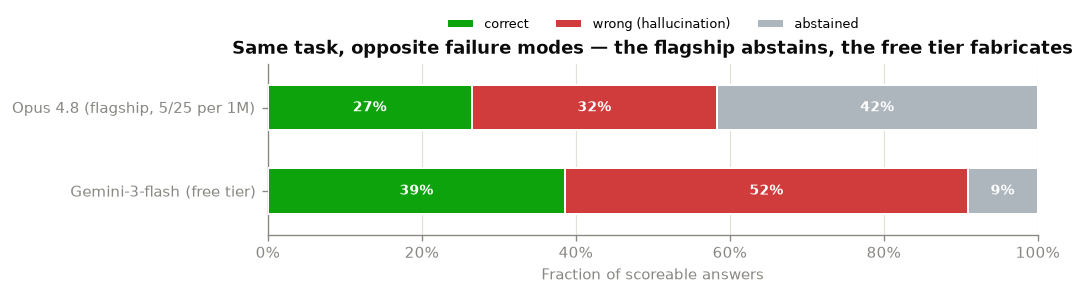


Reading: the flagship does NOT recall Florida code sections much better than the
free flash model — correct-citation rates are within ~12 points, both poor. What
changes is the failure mode. The flash model fills the gap by inventing a citation
(high hallucination, low abstention); the flagship fills it by declining to answer
('I don't have Section 202 memorized with enough precision' — verbatim). For a
compliance tool, a model that abstains is far safer than one that fabricates — but
neither is usable cold. Both need the retrieval grounding tested in Lesson 4.


In [10]:
# Compare the two cold runs by outcome type. Uses the same normalize-then-match
# logic as Section 1 so the numbers are apples-to-apples.
# The committed reference run is foundation_gemini3flash_raw.jsonl; a fresh
# `run_benchmark.py --model-class foundation_gemini` writes foundation_gemini_raw.jsonl
# (the harness names files by model class) — accept whichever exists.
_gemini_candidates = [RESULTS_DIR / "foundation_gemini3flash_raw.jsonl",
                      RESULTS_DIR / "foundation_gemini_raw.jsonl"]
comparison_files = {
    "Opus 4.8 (flagship, $5/$25 per 1M)": RESULTS_DIR / "foundation_raw.jsonl",
    "Gemini-3-flash (free tier)": next((p for p in _gemini_candidates if p.exists()),
                                       _gemini_candidates[0]),
}

def outcome_breakdown(path: Path) -> dict | None:
    if not path.exists():
        return None
    df = load_jsonl(path)
    df = df[df["error"].isna()].copy()
    df = df.merge(gold, left_on="question_id", right_on="question_id", suffixes=("", "_gold"))
    df["gold_norm"] = df["gold_section"].astype(str).map(extract_section_citation)
    df = df[df["gold_norm"].notna()]  # drop unscoreable golds (q017)
    n = len(df)
    matched = int((df["cited_section"] == df["gold_norm"]).sum())
    no_cite = int(df["cited_section"].isna().sum())
    wrong = n - matched - no_cite
    return {
        "scoreable_n": n,
        "correct_citation": matched / n,
        "wrong_citation (hallucination)": wrong / n,
        "no_citation (abstention)": no_cite / n,
        "mean_cost_usd": df["cost_usd"].mean(),
    }

comparison = {name: b for name, path in comparison_files.items()
              if (b := outcome_breakdown(path)) is not None}
comp_df = pd.DataFrame(comparison).T
display(comp_df.style.format({
    "correct_citation": "{:.1%}", "wrong_citation (hallucination)": "{:.1%}",
    "no_citation (abstention)": "{:.1%}", "mean_cost_usd": "${:.5f}", "scoreable_n": "{:.0f}",
}))

if len(comp_df) == 2:
    # Same stacked-outcome form and styling as Section 2, so the two cold
    # foundation runs read in the same visual language as the three-tier chart.
    _cols = ["correct_citation", "wrong_citation (hallucination)", "no_citation (abstention)"]
    fig, ax = plt.subplots(figsize=(9, 2.6))
    comp_df[_cols].plot(kind="barh", stacked=True, ax=ax,
                        color=[STATUS["correct"], STATUS["wrong"], STATUS["abstained"]],
                        edgecolor="white", linewidth=1.2, width=0.55, zorder=3)
    for i, (_name, row) in enumerate(comp_df.iterrows()):   # direct segment labels
        left = 0.0
        for k in _cols:
            v = row[k]
            if v > 0.06:
                ax.text(left + v / 2, i, f"{v:.0%}", ha="center", va="center",
                        color="white", fontsize=8.5, weight="bold", zorder=4)
            left += v
    ax.set_xlim(0, 1); ax.set_xlabel("Fraction of scoreable answers")
    ax.xaxis.set_major_formatter(lambda x, _pos: f"{x:.0%}")
    ax.set_title("Same task, opposite failure modes — the flagship abstains, the free tier fabricates")
    ax.grid(axis="y", visible=False)
    ax.legend(["correct", "wrong (hallucination)", "abstained"],
              loc="lower center", bbox_to_anchor=(0.5, 1.12), ncol=3, fontsize=8, frameon=False)
    ax.invert_yaxis()
    plt.tight_layout()
    # Exported for the write-ups, same pattern as grounding_slope.png.
    fig.savefig(RESULTS_DIR / "foundation_calibration.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(
        "\nReading: the flagship does NOT recall Florida code sections much better than the\n"
        "free flash model — correct-citation rates are within ~12 points, both poor. What\n"
        "changes is the failure mode. The flash model fills the gap by inventing a citation\n"
        "(high hallucination, low abstention); the flagship fills it by declining to answer\n"
        "('I don't have Section 202 memorized with enough precision' — verbatim). For a\n"
        "compliance tool, a model that abstains is far safer than one that fabricates — but\n"
        "neither is usable cold. Both need the retrieval grounding tested in Lesson 4."
    )

## 6. Lesson 5 — router selection comparison

Rather than ship yet another model router, Lesson 5 **dry-runs** several routers over the eval set — recording *which model each would pick, and whether it grounds*, without calling the model — and plots the selections on **model strength × grounding**. Two real routers (RouteLLM in Docker, NotDiamond via its API) plus a transparent difficulty heuristic are compared against a grounding-first custom router.

It then tests the sharpest objection — *can you leverage NotDiamond instead of hand-building a router?* — by (a) feeding it the **grounded** prompt (default router → picks strong) and (b) **training** a custom NotDiamond router on our citation scores ([`run_notdiamond_training.py`](../run_notdiamond_training.py) → picks cheap+grounded, matching the custom router). The chart is generated by [`router_comparison.py`](router_comparison.py) from [`results/router_selections.csv`](../results/router_selections.csv). Full method, numbers, and parameter provenance: [`FINDINGS.md`](../FINDINGS.md) § Lesson 5.

Router selection gravity (WHICH model each picks, and would it ground):

  routellm               strong   11% | grounded    0%  (n=45)
  notdiamond             strong   42% | grounded    0%  (n=45)
  notdiamond_grounded    strong   98% | grounded  100%  (n=44)
  notdiamond_trained     strong    0% | grounded  100%  (n=44)
  difficulty_baseline    strong   44% | grounded    0%  (n=45)
  custom                 strong    0% | grounded  100%  (n=45)


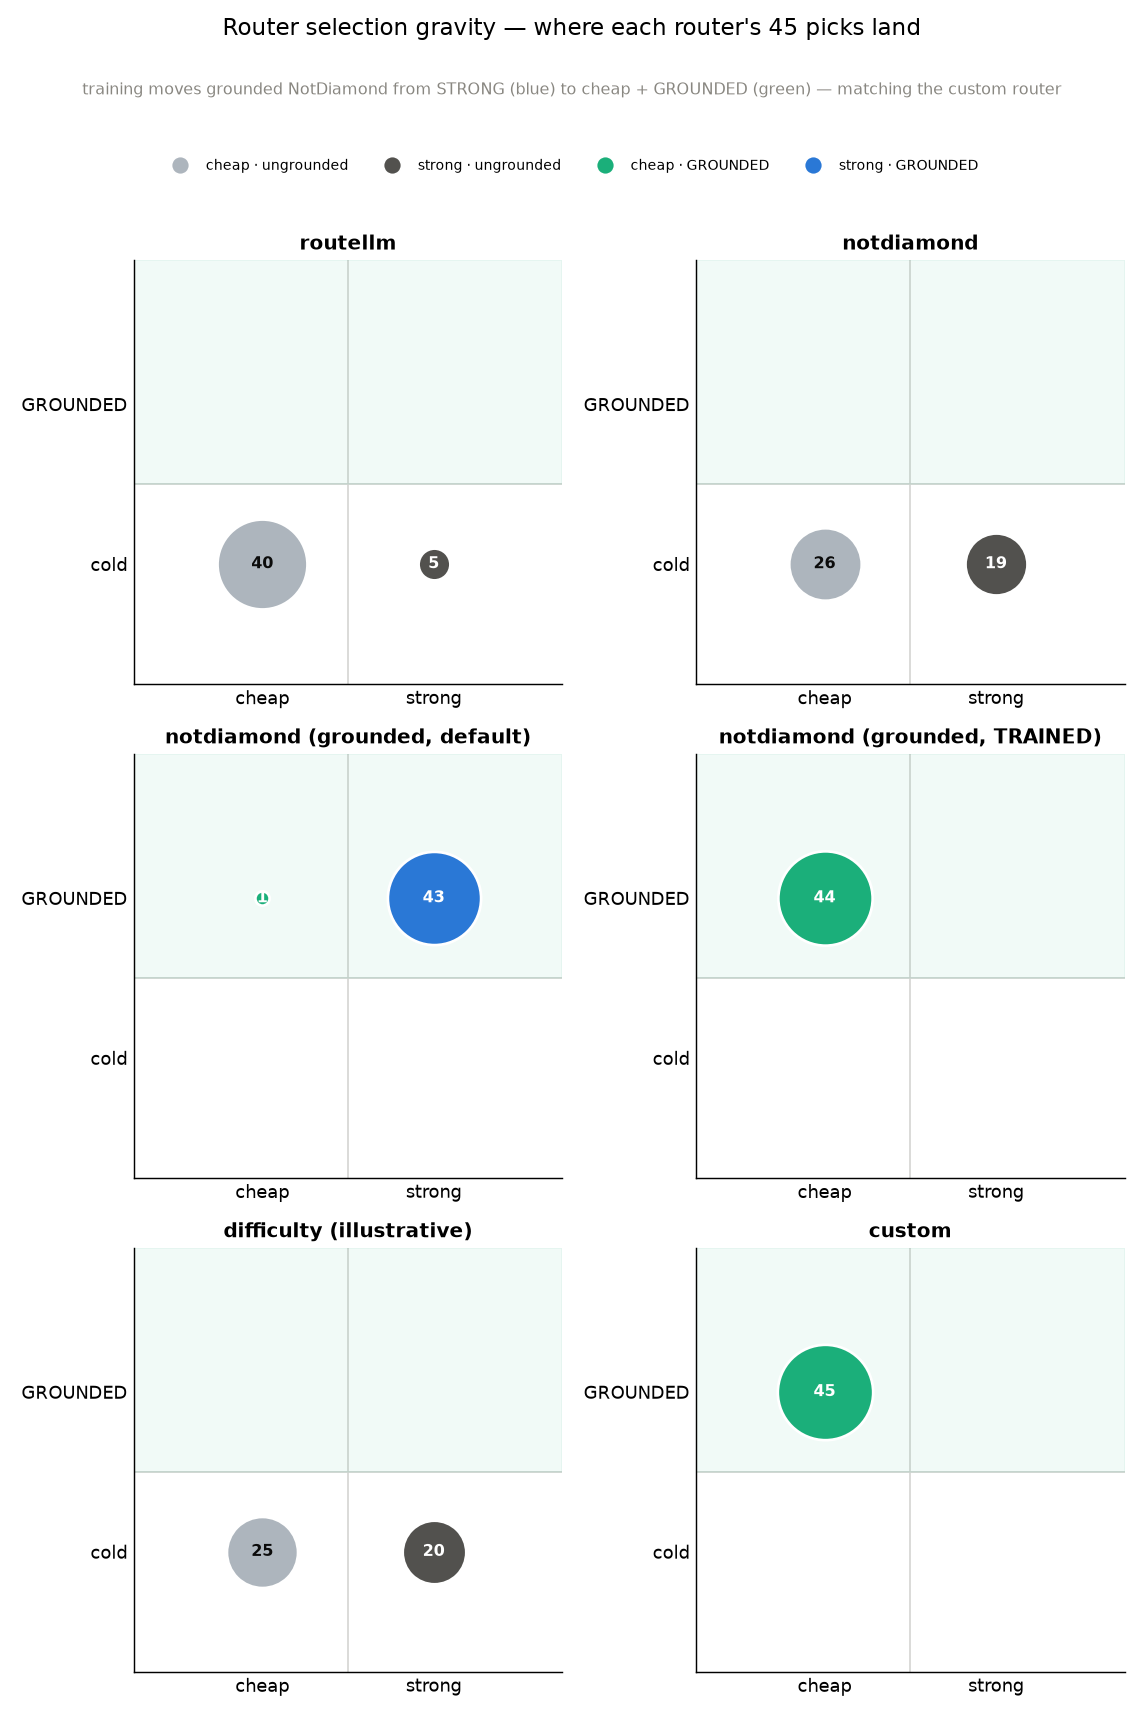


Cold, every off-the-shelf router lands 100% UNGROUNDED (~30%): grounding is a pipeline
decision, orthogonal to model-tier, that they don't expose out of the box. But it's
LEVERAGEABLE:
  - hand NotDiamond the GROUNDED prompt (default): it grounds but picks STRONG (~61%)
  - TRAIN a NotDiamond custom router on citation scores: cheap + GROUNDED 44/44 (~77%)
The trained off-the-shelf router MATCHES the hand-built custom router (~71%) — so you do
NOT need to build one. Custom's only durable edge is cost: it routes a third of questions
to a FREE local phi3, which NotDiamond's hosted catalog can't. See FINDINGS.md § Lesson 5.


In [11]:
import csv as _csv
from IPython.display import Image, display as _display

sel_path = RESULTS_DIR / "router_selections.csv"
png_path = RESULTS_DIR / "router_selection_gravity.png"

if sel_path.exists():
    rows = [r for r in _csv.DictReader(sel_path.open(encoding="utf-8")) if r["strength"] != "ERROR"]
    ORDER = ["routellm", "notdiamond", "notdiamond_grounded", "notdiamond_trained",
             "difficulty_baseline", "custom"]
    routers = [r for r in ORDER if r in {x["router"] for x in rows}]

    print("Router selection gravity (WHICH model each picks, and would it ground):\n")
    for rt in routers:
        s = [r for r in rows if r["router"] == rt]
        strong = sum(r["strength"] == "strong" for r in s)
        grounded = sum(r["grounded"] == "True" for r in s)
        print(f"  {rt:22} strong {strong / len(s):5.0%} | grounded {grounded / len(s):5.0%}  (n={len(s)})")

    if png_path.exists():
        _display(Image(filename=str(png_path)))

    print(
        "\nCold, every off-the-shelf router lands 100% UNGROUNDED (~30%): grounding is a pipeline\n"
        "decision, orthogonal to model-tier, that they don't expose out of the box. But it's\n"
        "LEVERAGEABLE:\n"
        "  - hand NotDiamond the GROUNDED prompt (default): it grounds but picks STRONG (~61%)\n"
        "  - TRAIN a NotDiamond custom router on citation scores: cheap + GROUNDED 44/44 (~77%)\n"
        "The trained off-the-shelf router MATCHES the hand-built custom router (~71%) — so you do\n"
        "NOT need to build one. Custom's only durable edge is cost: it routes a third of questions\n"
        "to a FREE local phi3, which NotDiamond's hosted catalog can't. See FINDINGS.md § Lesson 5."
    )
else:
    print("results/router_selections.csv not found — run the router dry-run first:\n"
          "  docker compose run --rm routers     (see FINDINGS.md § Lesson 5)")

## 8. Lesson 2 — the structured-output tradeoff

Lesson 2 swaps the flagship for a cheap mid-tier instruction-tuned model (Claude Haiku 4.5) and holds it to a rigid JSON schema. The question isn't "is the cheap model worse" — it's what the *schema contract itself* does to the failure profile. The result is the sharpest finding in the series so far: **forcing structure converts honest abstention into confident fabrication, at no gain in correctness.**

Instruction-tuned schema-valid rate: 99.3% (134/135)


,correct,wrong (hallucination),abstained,mean_cost_usd,p50_latency_ms
Opus 4.8 (free prose — may abstain),26.5%,31.8%,41.7%,$0.01046,6632 ms
Haiku 4.5 (forced JSON schema),31.8%,67.4%,0.8%,$0.00036,840 ms


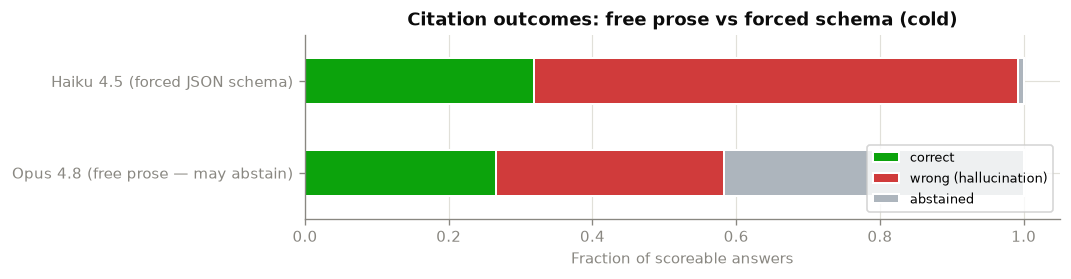


The schema contract is honored ~99% of the time — Haiku returns clean JSON.
But the `section` field is REQUIRED, so the model can never say 'I don't know':
abstention collapses from ~42% (Opus) to <1% (Haiku), and almost all of that mass
reappears as WRONG citations (hallucination ~2x higher). Correct-citation rate does
NOT improve — structure bought schema-validity and 29x lower cost and 8x lower
latency, but it removed the model's safest failure mode. For a permitting integration
that consumes the JSON downstream, that is the whole point: a schema guarantees a
parseable answer, not a correct one, and it actively suppresses 'I'm not sure.'


In [12]:
# Foundation (free prose, can abstain) vs instruction-tuned (forced JSON schema).
if not merged.empty and {"foundation", "instruction_tuned"}.issubset(set(merged["model_class"])):
    cold = merged[~merged["grounded"]]

    # Schema-compliance rate: did Haiku honor the JSON contract? (foundation rows
    # have no schema_valid field -> NaN, excluded.)
    it_rows = cold[cold["model_class"] == "instruction_tuned"]
    if "schema_valid" in it_rows.columns:
        sv = it_rows["schema_valid"].dropna()
        print(f"Instruction-tuned schema-valid rate: {sv.mean():.1%} ({int(sv.sum())}/{len(sv)})")

    def profile(mc: str) -> dict:
        sc = cold[(cold["model_class"] == mc) & cold["gold_section_norm"].notna()]
        n = len(sc)
        matched = int(sc["citation_correct"].sum())
        no_cite = int(sc["cited_section"].isna().sum())
        return {
            "correct": matched / n,
            "wrong (hallucination)": (n - matched - no_cite) / n,
            "abstained": no_cite / n,
            "mean_cost_usd": cold.loc[cold["model_class"] == mc, "cost_usd"].mean(),
            "p50_latency_ms": cold.loc[cold["model_class"] == mc, "latency_ms"].median(),
        }

    labels = {"foundation": "Opus 4.8 (free prose — may abstain)",
              "instruction_tuned": "Haiku 4.5 (forced JSON schema)"}
    prof = pd.DataFrame({labels[mc]: profile(mc) for mc in ["foundation", "instruction_tuned"]}).T
    display(prof.style.format({
        "correct": "{:.1%}", "wrong (hallucination)": "{:.1%}", "abstained": "{:.1%}",
        "mean_cost_usd": "${:.5f}", "p50_latency_ms": "{:.0f} ms",
    }))

    # Reserved STATUS palette (same correct/wrong/abstained colors as Sections 2 and 7).
    prof[["correct", "wrong (hallucination)", "abstained"]].plot(
        kind="barh", stacked=True, figsize=(9, 2.4),
        color=[STATUS["correct"], STATUS["wrong"], STATUS["abstained"]],
        edgecolor="white", linewidth=1.2)
    plt.xlabel("Fraction of scoreable answers")
    plt.title("Citation outcomes: free prose vs forced schema (cold)")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    print(
        "\nThe schema contract is honored ~99% of the time — Haiku returns clean JSON.\n"
        "But the `section` field is REQUIRED, so the model can never say 'I don't know':\n"
        "abstention collapses from ~42% (Opus) to <1% (Haiku), and almost all of that mass\n"
        "reappears as WRONG citations (hallucination ~2x higher). Correct-citation rate does\n"
        "NOT improve — structure bought schema-validity and 29x lower cost and 8x lower\n"
        "latency, but it removed the model's safest failure mode. For a permitting integration\n"
        "that consumes the JSON downstream, that is the whole point: a schema guarantees a\n"
        "parseable answer, not a correct one, and it actively suppresses 'I'm not sure.'"
    )
else:
    print("Need both foundation and instruction_tuned runs. Run:\n"
          "  python run_benchmark.py --model-class instruction_tuned --repeats 3")